In [2]:

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json 
sns.set()

sys.path.append(os.path.abspath(os.path.join('..')))
# 2. Modeling Candidates
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    classification_report, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)


import joblib # Often better for heavy numpy-based pickles
from src.logger import logging
from src.exception import CustomException
from src.components.preprocessing import handle_handset_price, cap_outliers
from src.utils import load_object 

# 5. Notebook Configuration
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Set Global Seed for Reproducibility
RANDOM_STATE = 42

print("Laboratory Environment Initialized. Ready for Experimentation.")

Laboratory Environment Initialized. Ready for Experimentation.


In [3]:
train_file_path = os.path.join("..", "artifacts", "data", "train_array.npy")
test_file_path = os.path.join("..", "artifacts", "data", "test_array.npy")

try:
    logging.info("Loading the arrays")

    train_array = np.load(train_file_path)
    test_array = np.load(test_file_path)


    # Slicing 
    x_train, y_train = train_array[:,:-1], train_array[:,-1]      
    x_test, y_test = test_array[:,:-1], test_array[:,-1]     

    logging.info(f"Successfully loaded and sliced data.")

    print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}") 
    print(f"X_test shape: {x_test.shape}, y_test shape: {y_test.shape}")
except Exception as e:
    raise CustomException(e, sys)    

x_train shape: (40837, 45), y_train shape: (40837,)
X_test shape: (10210, 45), y_test shape: (10210,)


In [4]:
lr_model = LogisticRegression(
    class_weight="balanced", 
    max_iter=1000,
    random_state=RANDOM_STATE
)
logging.info("Training Logistic Regression Baseline")

lr_model.fit(x_train, y_train)

y_pred = lr_model.predict(x_test)
y_prob = lr_model.predict_proba(x_test)[:, 1] # the slicing gets us the proba of churn not proba of not churn

logging.info("Baseline Logistic Regression Training Complete")


In [5]:
# 1. Basic Classification Report
print("--- Logistic Regression Baseline Report ---")
print(classification_report(y_test, y_pred))


--- Logistic Regression Baseline Report ---
              precision    recall  f1-score   support

         0.0       0.77      0.57      0.66      7268
         1.0       0.36      0.59      0.44      2942

    accuracy                           0.57     10210
   macro avg       0.57      0.58      0.55     10210
weighted avg       0.65      0.57      0.59     10210



In [6]:
auc_score = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {auc_score:.4f}")

ROC-AUC Score: 0.6043


In [7]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[4127, 3141],
       [1203, 1739]])

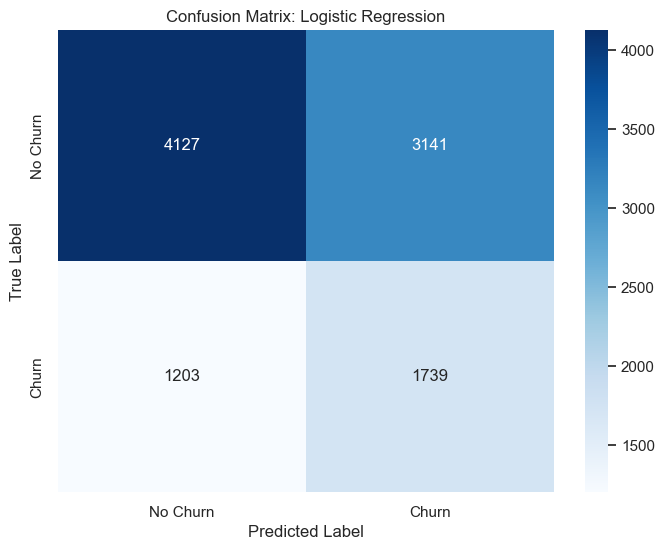

In [8]:
# 3. Visualizing the Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'], 
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

In [9]:
try:
    rf_model = RandomForestClassifier(
        n_estimators=100, # 100 trees 
        max_depth=10, # Limit depth to prevent overfitting early on
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=1 # Use all your CPU cores for speed
    )

    logging.info("Training Random Forest Baseline")
    rf_model.fit(x_train, y_train)

    y_pred_rf = rf_model.predict(x_test)
    y_prob_rf = rf_model.predict_proba(x_test)[:, 1]
except Exception as e:
    raise CustomException(e, sys)


In [10]:
print("--- Random Forrest Baseline Report ---")
print(classification_report(y_test, y_pred_rf))


--- Random Forrest Baseline Report ---
              precision    recall  f1-score   support

         0.0       0.80      0.57      0.67      7268
         1.0       0.38      0.64      0.48      2942

    accuracy                           0.60     10210
   macro avg       0.59      0.61      0.57     10210
weighted avg       0.68      0.60      0.61     10210



In [11]:
auc_score2 = roc_auc_score(y_test, y_prob_rf)
print(f"ROC-AUC Score: {auc_score2:.4f}")

ROC-AUC Score: 0.6533


In [12]:
y_pred_rf_agg = (y_prob_rf > 0.35).astype(int)

print("--- Random Forrest Baseline Report 2---")
print(classification_report(y_test, y_pred_rf_agg))


--- Random Forrest Baseline Report 2---
              precision    recall  f1-score   support

         0.0       0.86      0.20      0.32      7268
         1.0       0.32      0.92      0.47      2942

    accuracy                           0.41     10210
   macro avg       0.59      0.56      0.40     10210
weighted avg       0.71      0.41      0.37     10210



In [32]:
auc_score3 = roc_auc_score(y_test, y_pred_rf_agg)
print(f"ROC-AUC Score: {auc_score3:.4f}")

ROC-AUC Score: 0.5608


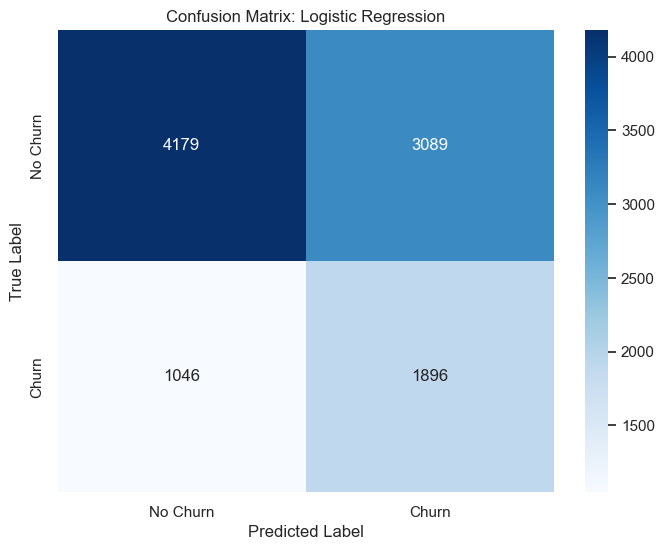

In [13]:
cm2 = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))

sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'], 
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

In [14]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,             # XGBoost trees are usually shallower than RF
    learning_rate=0.1,       # The "Step Size" for learning from mistakes
    scale_pos_weight=2.44,   # Addressing your ~29% churn rate
    random_state=RANDOM_STATE,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='logloss'
)

logging.info("Training XGBoost Baseline")
xgb_model.fit(x_train, y_train)

y_pred_xgb = xgb_model.predict(x_test)
y_prob_xgb = xgb_model.predict_proba(x_test)[:, 1]

In [15]:
print("--- XGBOOST Baseline Report ---")
print(classification_report(y_test, y_pred_xgb))

--- XGBOOST Baseline Report ---
              precision    recall  f1-score   support

         0.0       0.80      0.64      0.71      7268
         1.0       0.40      0.60      0.48      2942

    accuracy                           0.62     10210
   macro avg       0.60      0.62      0.59     10210
weighted avg       0.68      0.62      0.64     10210



In [16]:
cm3 = confusion_matrix(y_test, y_pred_xgb)
cm3

array([[4624, 2644],
       [1186, 1756]])

In [17]:
# 1. Get Importances
importances = xgb_model.feature_importances_

In [18]:
preprocessor = load_object("../artifacts/models/preprocessor.pkl")

with open("../artifacts/data/feature_names.json", "r") as f:
    feature_names = json.load(f)

print(f"✅ System Synced. We have {len(feature_names)} feature names ready for XGBoost.")    

✅ System Synced. We have 45 feature names ready for XGBoost.


In [19]:
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index()

print(importance_df)

    index                                            Feature  Importance
0      18           extreme_clean_lane__CurrentEquipmentDays    0.066414
1      26            categorical_lane__HandsetRefurbished_No    0.066158
2      19                 stable_messy_lane__MonthsInService    0.055109
3      34               categorical_lane__CreditRating_5-Low    0.046050
4      25  stable_messy_lane__missingindicator_TotalRecur...    0.035152
5       9                 extreme_messy_lane__MonthlyMinutes    0.034465
6      28             categorical_lane__HandsetWebCapable_No    0.033731
7      10              extreme_messy_lane__PercChangeMinutes    0.033250
8      23            stable_messy_lane__TotalRecurringCharge    0.033166
9       4      lying_zero_lane__missingindicator_IncomeGroup    0.032354
10      7                 extreme_messy_lane__OverageMinutes    0.028471
11      8             extreme_messy_lane__PercChangeRevenues    0.026758
12     33            categorical_lane__CreditRating

In [20]:


y_pred_aggressive = (y_prob_xgb > 0.35).astype(int)

print("--- Aggressive Model Performance (Threshold = 0.35) ---")
print(classification_report(y_test, y_pred_aggressive))

--- Aggressive Model Performance (Threshold = 0.35) ---
              precision    recall  f1-score   support

         0.0       0.85      0.30      0.44      7268
         1.0       0.34      0.87      0.48      2942

    accuracy                           0.46     10210
   macro avg       0.59      0.59      0.46     10210
weighted avg       0.70      0.46      0.46     10210



In [21]:
prob_table = pd.DataFrame({"RF_prob": y_prob_rf,
                             "XGB_prob": y_prob_xgb
})
prob_table["Ensemble_prob"] = (prob_table["RF_prob"] + prob_table["XGB_prob"]) / 2
prob_table

,RF_prob,XGB_prob,Ensemble_prob
0,0.452528,0.513066,0.482797
1,0.550628,0.599001,0.574815
2,0.549427,0.607013,0.578220
3,0.557224,0.551071,0.554147
4,0.581044,0.599774,0.590409
...,...,...,...
10205,0.529476,0.488504,0.508990
10206,0.538585,0.548829,0.543707
10207,0.617507,0.761705,0.689606
10208,0.540514,0.560146,0.550330


In [22]:
df_test = pd.read_csv("../artifacts/data/test.csv")
df_test.shape, test_array.shape

((10210, 21), (10210, 46))

In [23]:
prob_table["MonthlyRevenue"] = df_test["MonthlyRevenue"].values

# Find the top 20% of earners
revenue_cutoff = prob_table["MonthlyRevenue"].quantile(0.80)

print(f"💰 The current VIP threshold is: ${revenue_cutoff:.2f}")

💰 The current VIP threshold is: $78.92


In [24]:
def assing_action(row, cutoff):
    prob = row["Ensemble_prob"]
    rev = row['MonthlyRevenue']

    if rev >= cutoff:
        if prob > 0.35:
            return "CRITICAL: Call Now"
        else: return "VIP: Priority Monitor"

    else: 
        if prob > 0.50: return "HIGH: SMS/Email Offer"
        else: return "stable"    

In [25]:
prob_table["Action_Plan"] = prob_table.apply(assing_action, args=(revenue_cutoff,), axis=1)
prob_table

,RF_prob,XGB_prob,Ensemble_prob,MonthlyRevenue,Action_Plan
0,0.452528,0.513066,0.482797,14.16,stable
1,0.550628,0.599001,0.574815,12.96,HIGH: SMS/Email Offer
2,0.549427,0.607013,0.578220,55.86,HIGH: SMS/Email Offer
3,0.557224,0.551071,0.554147,37.19,HIGH: SMS/Email Offer
4,0.581044,0.599774,0.590409,60.76,HIGH: SMS/Email Offer
...,...,...,...,...,...
10205,0.529476,0.488504,0.508990,33.01,HIGH: SMS/Email Offer
10206,0.538585,0.548829,0.543707,47.70,HIGH: SMS/Email Offer
10207,0.617507,0.761705,0.689606,78.07,HIGH: SMS/Email Offer
10208,0.540514,0.560146,0.550330,57.12,HIGH: SMS/Email Offer


In [26]:
prob_table["Actual_Churn"] = y_test
prob_table

,RF_prob,XGB_prob,Ensemble_prob,MonthlyRevenue,Action_Plan,Actual_Churn
0,0.452528,0.513066,0.482797,14.16,stable,0.0
1,0.550628,0.599001,0.574815,12.96,HIGH: SMS/Email Offer,0.0
2,0.549427,0.607013,0.578220,55.86,HIGH: SMS/Email Offer,1.0
3,0.557224,0.551071,0.554147,37.19,HIGH: SMS/Email Offer,0.0
4,0.581044,0.599774,0.590409,60.76,HIGH: SMS/Email Offer,1.0
...,...,...,...,...,...,...
10205,0.529476,0.488504,0.508990,33.01,HIGH: SMS/Email Offer,0.0
10206,0.538585,0.548829,0.543707,47.70,HIGH: SMS/Email Offer,0.0
10207,0.617507,0.761705,0.689606,78.07,HIGH: SMS/Email Offer,0.0
10208,0.540514,0.560146,0.550330,57.12,HIGH: SMS/Email Offer,0.0


In [27]:
prob_table["Policy_Pred"] = prob_table['Action_Plan'].apply(
    lambda x:1 if "CRITICAL" in x or "HIGH" in x else 0
)

prob_table[["Action_Plan", "Policy_Pred", "Actual_Churn"]].head(10)

,Action_Plan,Policy_Pred,Actual_Churn
0,stable,0,0.0
1,HIGH: SMS/Email Offer,1,0.0
2,HIGH: SMS/Email Offer,1,1.0
3,HIGH: SMS/Email Offer,1,0.0
4,HIGH: SMS/Email Offer,1,1.0
5,HIGH: SMS/Email Offer,1,1.0
6,HIGH: SMS/Email Offer,1,0.0
7,CRITICAL: Call Now,1,0.0
8,stable,0,0.0
9,HIGH: SMS/Email Offer,1,0.0


In [28]:
is_vip = prob_table["MonthlyRevenue"] >= 78.92

# 2. Evaluation for VIPs (The ones we protected with 0.35 threshold)
print("📊 --- VIP SEGMENT (Top 20% Revenue) ---")
print(classification_report(prob_table[is_vip]["Actual_Churn"], 
                            prob_table[is_vip]["Policy_Pred"]))

# 3. Evaluation for Standard Pool (The ones we checked with 0.50 threshold)
print("\n📊 --- STANDARD SEGMENT (Bottom 80% Revenue) ---")
print(classification_report(prob_table[~is_vip]["Actual_Churn"], 
                            prob_table[~is_vip]["Policy_Pred"]))

📊 --- VIP SEGMENT (Top 20% Revenue) ---
              precision    recall  f1-score   support

         0.0       0.83      0.28      0.42      1472
         1.0       0.31      0.85      0.46       565

    accuracy                           0.44      2037
   macro avg       0.57      0.57      0.44      2037
weighted avg       0.69      0.44      0.43      2037


📊 --- STANDARD SEGMENT (Bottom 80% Revenue) ---
              precision    recall  f1-score   support

         0.0       0.80      0.59      0.68      5796
         1.0       0.39      0.65      0.49      2377

    accuracy                           0.61      8173
   macro avg       0.60      0.62      0.59      8173
weighted avg       0.69      0.61      0.63      8173



In [30]:
auc_score_vip = roc_auc_score(prob_table[is_vip]["Actual_Churn"], prob_table[is_vip]["Policy_Pred"])
print(f"ROC-AUC Score Vip: {auc_score_vip:.4f}")

ROC-AUC Score Vip: 0.5664


In [31]:
auc_score_no_vip = roc_auc_score(prob_table[~is_vip]["Actual_Churn"], prob_table[~is_vip]["Policy_Pred"])
print(f"ROC-AUC Score Vip: {auc_score_no_vip:.4f}")

ROC-AUC Score Vip: 0.6204
